In [ ]:
!nvidia-smi

Thu Sep 17 18:12:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ── Cell 2: Imports ──────────────────────────────────────────
import os, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score,
    brier_score_loss
)
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ── Cell 4: Paths ────────────────────────────────────────────
import os

BASE_PATH = "/content/drive/MyDrive/REFUGE-2/Refuge2_data"

TRAIN_CSV = f"{BASE_PATH}/Refuge2_data/Train.csv"
VAL_CSV   = f"{BASE_PATH}/Refuge2_data/val.csv"
TEST_CSV  = f"{BASE_PATH}/Refuge2_data/Test.csv"

TRAIN_IMG = f"{BASE_PATH}/train_rgb_roi"
VAL_IMG   = f"{BASE_PATH}/val_rgb_roi"
TEST_IMG  = f"{BASE_PATH}/test_rgb_roi"

SAVE_DIR  = "/content/drive/MyDrive/REFUGE2_RESULTS"
os.makedirs(SAVE_DIR, exist_ok=True)

# Verify all paths exist
for path in [TRAIN_CSV, VAL_CSV, TEST_CSV,
             TRAIN_IMG, VAL_IMG, TEST_IMG]:
    assert os.path.exists(path), f" Path not found: {path}"

print(" All dataset paths verified.")

 All dataset paths verified.


In [ ]:
# ── Cell 5: Dataset Class ─────────────────────────────────────
class REFUGE2Dataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data    = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        # Auto-detect image column
        self.img_col = None
        for col in ["ImgName", "FileName", "data", "image", "filename"]:
            if col in self.data.columns:
                self.img_col = col
                break
        if self.img_col is None:
            raise ValueError(f"No image column found. Columns: {list(self.data.columns)}")

        # Auto-detect label column
        self.label_col = None
        for col in ["glaucoma", "Label", "label", "class"]:
            if col in self.data.columns:
                self.label_col = col
                break
        if self.label_col is None:
            raise ValueError(f"No label column found. Columns: {list(self.data.columns)}")

        print(f"  Using image col='{self.img_col}', label col='{self.label_col}'")
        print(f"  Total samples: {len(self.data)}")
        print(f"  Class distribution:\n{self.data[self.label_col].value_counts().to_string()}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = str(self.data.iloc[idx][self.img_col])
        label    = float(self.data.iloc[idx][self.label_col])
        img_path = os.path.join(self.img_dir, img_name)

        # Handle missing extension
        if not os.path.exists(img_path):
            for ext in [".jpg", ".png", ".jpeg"]:
                if os.path.exists(img_path + ext):
                    img_path = img_path + ext
                    break

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.float32)

In [ ]:
# ── Cell 6: Transforms ──  BUG FIX: Normalize was MISSING ──
# EfficientNetB3 expects ImageNet-normalized inputs.
# Original NB15 was missing this — all results were invalid.

IMG_SIZE = 300  # EfficientNetB3 optimal input size

#  FIXED transforms — Normalize is now present
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   #  FIXED
                         std=[0.229, 0.224, 0.225])
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   #  FIXED
                         std=[0.229, 0.224, 0.225])
])

print(" Transforms with Normalize defined correctly.")

 Transforms with Normalize defined correctly.


In [ ]:
# ── Cell 7: DataLoaders ──────────────────────────────────────
from torch.utils.data import DataLoader

train_ds = REFUGE2Dataset(TRAIN_CSV, TRAIN_IMG, train_tfms)
val_ds   = REFUGE2Dataset(VAL_CSV,   VAL_IMG,   test_tfms)
test_ds  = REFUGE2Dataset(TEST_CSV,  TEST_IMG,  test_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\n Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

  Using image col='ImgName', label col='glaucoma'
  Total samples: 1200
  Class distribution:
glaucoma
0    1080
1     120
  Using image col='FileName', label col='glaucoma'
  Total samples: 400
  Class distribution:
glaucoma
0    320
1     80
  Using image col='data', label col='glaucoma'
  Total samples: 400
  Class distribution:
glaucoma
0    320
1     80

 Train: 1200 | Val: 400 | Test: 400


Image name: T0001.jpg
Image path: /content/drive/MyDrive/REFUGE-2/Refuge2_data/test_rgb_roi/T0001.jpg
Original image size: (460, 460)


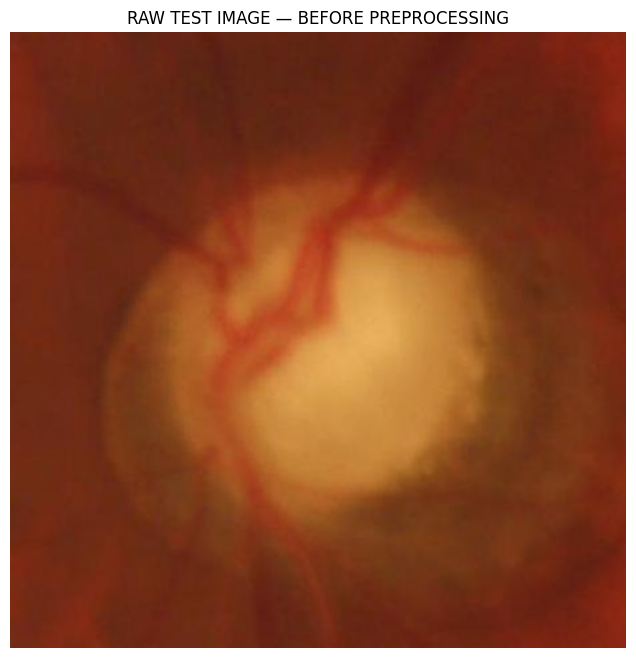

In [ ]:
# ============================================================
# IMAGE INSPECTION — CHECK WHETHER INPUT IS FULL FUNDUS OR ROI
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image
import os

# Pick one image from the TEST dataset
idx = 0

img_name = str(test_ds.data.iloc[idx][test_ds.img_col])
img_path = os.path.join(test_ds.img_dir, img_name)

# Handle missing extension
if not os.path.exists(img_path):
    for ext in [".jpg", ".png", ".jpeg"]:
        if os.path.exists(img_path + ext):
            img_path = img_path + ext
            break

# Load ORIGINAL image BEFORE any resizing/normalization
raw_img = Image.open(img_path).convert("RGB")

print("Image name:", img_name)
print("Image path:", img_path)
print("Original image size:", raw_img.size)

# Display image
plt.figure(figsize=(8, 8))
plt.imshow(raw_img)
plt.axis("off")
plt.title("RAW TEST IMAGE — BEFORE PREPROCESSING")
plt.show()

In [ ]:
# ── Cell 8: Focal Loss ───────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss for class-imbalanced glaucoma detection.
    alpha: weight for positive class (glaucoma is minority)
    gamma: focusing parameter (2.0 is standard)
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce   = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt       = torch.exp(-bce_loss)
        loss     = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return loss.mean()

In [ ]:
# ── Cell 9: Model ────────────────────────────────────────────
class GlaucomaEfficientNet(nn.Module):
    """
    EfficientNetB3 backbone with a binary classification head.
    Dropout added before final layer for regularization.
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        self.backbone = models.efficientnet_b3(
            weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        return self.backbone(x)

model     = GlaucomaEfficientNet(dropout=0.3).to(DEVICE)
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

#  NEW: LR Scheduler — cosine annealing with warmup-like restart
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=35, eta_min=1e-6
)

print(" Model, loss, optimizer, scheduler ready.")
print(f"   Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 125MB/s]


 Model, loss, optimizer, scheduler ready.
   Trainable params: 10,697,769


In [ ]:
# ── Cell 10: Training Loop ───────────────────────────────────
EPOCHS   = 35
best_auc = 0.0
history  = {"train_loss": [], "val_auc": [], "lr": []}

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    losses = []
    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.unsqueeze(1).float().to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    # ── Validate ──
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs  = imgs.to(DEVICE)
            probs = torch.sigmoid(model(imgs)).cpu().numpy()
            y_prob.extend(probs.flatten())
            y_true.extend(labels.numpy())

    val_auc   = roc_auc_score(y_true, y_prob)
    train_loss = np.mean(losses)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {train_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(),
                   f"{SAVE_DIR}/effnetb3_best.pth")
        print(f"   Saved best model (AUC={best_auc:.4f})")

print(f"\n Best Validation AUC: {best_auc:.4f}")

Epoch 01/35 | Loss: 0.0216 | Val AUC: 0.8619 | LR: 9.98e-05
   Saved best model (AUC=0.8619)
Epoch 02/35 | Loss: 0.0128 | Val AUC: 0.9022 | LR: 9.92e-05
   Saved best model (AUC=0.9022)
Epoch 03/35 | Loss: 0.0095 | Val AUC: 0.9096 | LR: 9.82e-05
   Saved best model (AUC=0.9096)
Epoch 04/35 | Loss: 0.0070 | Val AUC: 0.9345 | LR: 9.68e-05
   Saved best model (AUC=0.9345)
Epoch 05/35 | Loss: 0.0065 | Val AUC: 0.9395 | LR: 9.51e-05
   Saved best model (AUC=0.9395)
Epoch 06/35 | Loss: 0.0052 | Val AUC: 0.9291 | LR: 9.30e-05
Epoch 07/35 | Loss: 0.0037 | Val AUC: 0.9304 | LR: 9.05e-05
Epoch 08/35 | Loss: 0.0040 | Val AUC: 0.9043 | LR: 8.78e-05
Epoch 09/35 | Loss: 0.0047 | Val AUC: 0.9204 | LR: 8.47e-05
Epoch 10/35 | Loss: 0.0034 | Val AUC: 0.9252 | LR: 8.14e-05
Epoch 11/35 | Loss: 0.0020 | Val AUC: 0.9263 | LR: 7.78e-05
Epoch 12/35 | Loss: 0.0019 | Val AUC: 0.9209 | LR: 7.40e-05
Epoch 13/35 | Loss: 0.0018 | Val AUC: 0.9168 | LR: 7.00e-05
Epoch 14/35 | Loss: 0.0017 | Val AUC: 0.9171 | LR: 6.58

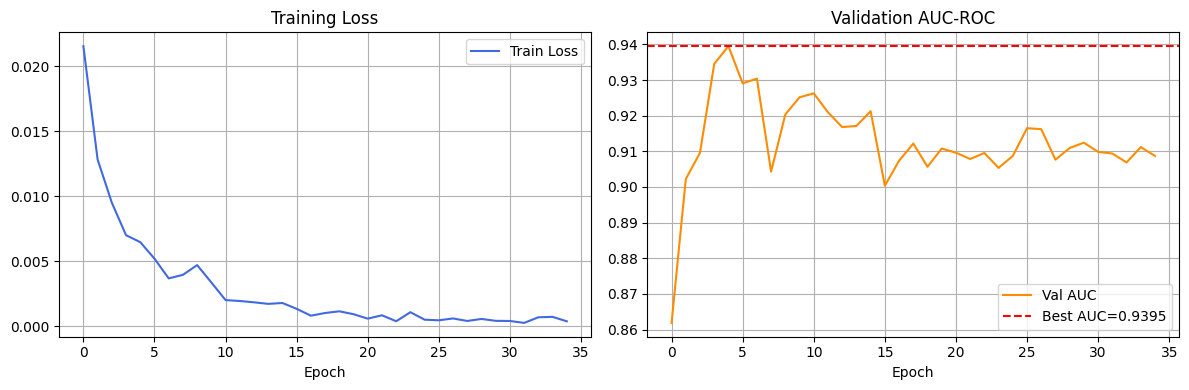

In [ ]:
# ── Cell 11: Training Curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss", color="royalblue")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["val_auc"], label="Val AUC", color="darkorange")
axes[1].axhline(best_auc, color="red", linestyle="--",
                label=f"Best AUC={best_auc:.4f}")
axes[1].set_title("Validation AUC-ROC"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/effnetb3_training_curves.png", dpi=150)
plt.show()

In [ ]:
# ── Cell 12: Test Evaluation (Youden Threshold) ──────────────
# Load best model
model.load_state_dict(torch.load(f"{SAVE_DIR}/effnetb3_best.pth",
                                  map_location=DEVICE))
model.eval()

y_true, y_prob = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs  = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs)).cpu().numpy()
        y_prob.extend(probs.flatten())
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Youden's J statistic for optimal threshold
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
youden_idx  = np.argmax(tpr - fpr)
best_thresh = float(thresholds[youden_idx])
y_pred      = (y_prob >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

results = {
    "Model":        "EfficientNetB3",
    "Dataset":      "REFUGE2",
    "Threshold":    round(best_thresh, 4),
    "Accuracy":     round(float(accuracy_score(y_true, y_pred)), 4),
    "Precision":    round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
    "Recall_Sensitivity": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
    "Specificity":  round(float(tn / (tn + fp)), 4),
    "F1_Score":     round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
    "ROC_AUC":      round(float(roc_auc_score(y_true, y_prob)), 4),
    "PR_AUC":       round(float(average_precision_score(y_true, y_prob)), 4),
    "Brier_Score":  round(float(brier_score_loss(y_true, y_prob)), 4),
    "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)
}

print("\n EfficientNetB3 Test Results:")
print("="*45)
for k, v in results.items():
    print(f"  {k:<28}: {v}")


 EfficientNetB3 Test Results:
  Model                       : EfficientNetB3
  Dataset                     : REFUGE2
  Threshold                   : 0.6164
  Accuracy                    : 0.8775
  Precision                   : 0.7183
  Recall_Sensitivity          : 0.6375
  Specificity                 : 0.9375
  F1_Score                    : 0.6755
  ROC_AUC                     : 0.8323
  PR_AUC                      : 0.7363
  Brier_Score                 : 0.1336
  TP                          : 51
  TN                          : 300
  FP                          : 20
  FN                          : 29


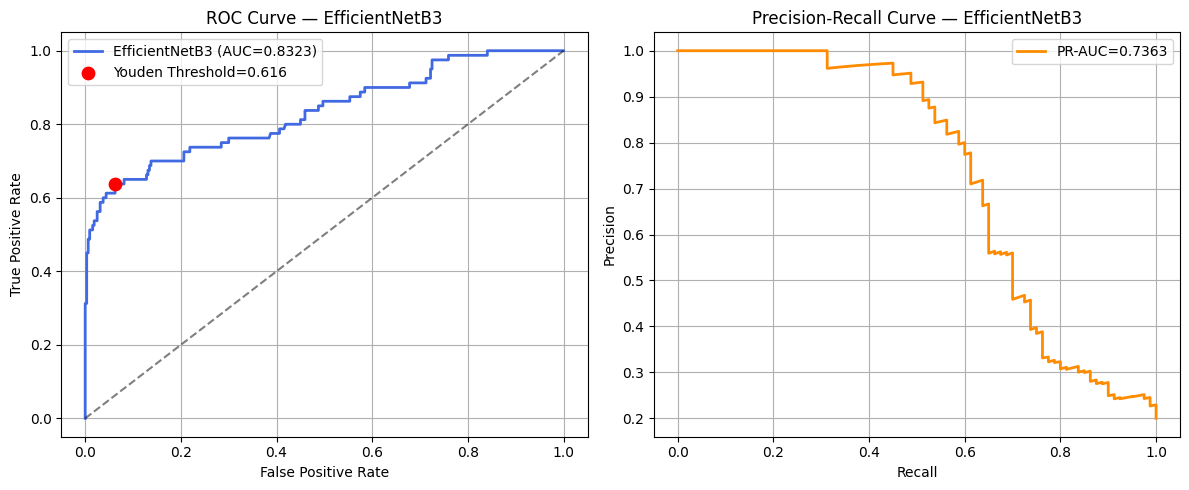

In [ ]:
# ── Cell 13: ROC + PR Curves ─────────────────────────────────
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color="royalblue", lw=2,
             label=f"EfficientNetB3 (AUC={results['ROC_AUC']:.4f})")
axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0].scatter(fpr[youden_idx], tpr[youden_idx],
                color='red', zorder=5, s=80,
                label=f"Youden Threshold={best_thresh:.3f}")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — EfficientNetB3")
axes[0].legend(); axes[0].grid(True)

# PR Curve
prec, rec, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(rec, prec, color="darkorange", lw=2,
             label=f"PR-AUC={results['PR_AUC']:.4f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — EfficientNetB3")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/effnetb3_roc_pr_curves.png", dpi=150)
plt.show()

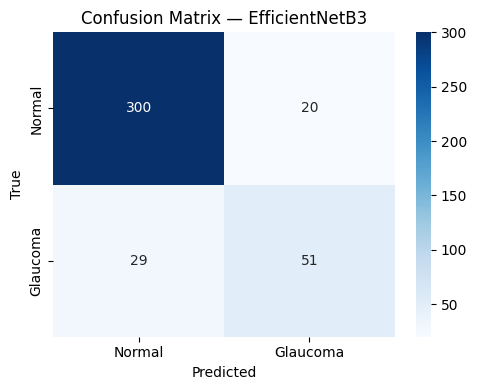

In [ ]:
# ── Cell 14: Confusion Matrix ────────────────────────────────
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal","Glaucoma"],
            yticklabels=["Normal","Glaucoma"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — EfficientNetB3")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/effnetb3_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                           num_workers=2, pin_memory=True,
                           worker_init_fn=seed_worker, generator=g)

In [ ]:
# ── Cell 15: Save All Results ────────────────────────────────
# Save metrics JSON
with open(f"{SAVE_DIR}/effnetb3_metrics.json", "w") as f:
    json.dump(results, f, indent=4)

# Save raw probabilities and labels (needed for NB16 calibration)
np.save(f"{SAVE_DIR}/test_probs_v2.npy", y_prob)
np.save(f"{SAVE_DIR}/test_labels_v2.npy", y_true)
torch.save(model.state_dict(), f"{SAVE_DIR}/effnetb3_v2_best.pth")

# Save training history
pd.DataFrame(history).to_csv(
    f"{SAVE_DIR}/effnetb3_training_history.csv", index=False
)

print(" All results saved to:", SAVE_DIR)
print("\nFiles saved:")
for f in os.listdir(SAVE_DIR):
    print(f"  {f}")

 All results saved to: /content/drive/MyDrive/REFUGE2_RESULTS

Files saved:
  MODEL15_EfficientNetB3.pth
  classification_metrics.json
  clinical_validation_report.json
  effnetb3_roc_pr_curves.png
  effnetb3_confusion_matrix.png
  cdr_calibration_fixed.png
  cdr_regression_results_fixed.json
  cdr_distribution_corrected.png
  cdr_hybrid_best.pth
  cdr_final_results.json
  cdr_regression_v3_final.png
  cdr_v3_results.json
  cdr_v3_training_history.csv
  paper_results_fig1.png
  paper_cdr_scatter_final.png
  paper_table1_classification.csv
  paper_table2_cdr_regression.csv
  paper_all_results.json
  resnet50_drishti_best.pth
  resnet50_baseline_metrics.json
  resnet50_test_probs.npy
  resnet50_test_labels.npy
  resnet50_training_history.csv
  resnet50_refuge2_best.pth
  resnet50_refuge2_training_curves.png
  resnet50_refuge2_eval_plots.png
  resnet50_refuge2_metrics.json
  resnet50_refuge2_probs.npy
  resnet50_refuge2_labels.npy
  resnet50_refuge2_training_history.csv
  effnetb3_best.pt